# CDC / SCD Type 2 Pipeline — End-to-End Column Lineage

**Example: A realistic Change Data Capture + Slowly Changing Dimension Type 2 pipeline, with column lineage through every layer.**

This notebook stress-tests clgraph against the kind of pipeline you actually see in production:

- **Raw CDC envelope** (Debezium-style `before`/`after` structs, operation codes)
- **Dedup staging** using `ROW_NUMBER()` + `WHERE rn = 1`
- **SCD2 target** via a two-step MERGE-then-INSERT pattern on the same dim table
- **Fact table** joined to the dim with a **point-in-time** range predicate
- **Mart** rollup by day and dimension attribute

Along the way it demonstrates ten column-lineage features that were gaps in clgraph before this iteration (see `docs/superpowers/specs/2026-04-13-cdc-scd-pipeline-gaps-design.md`):

| # | Feature | Edge / metadata |
|---|---------|-----------------|
| 1 | Struct dot-access on CDC envelope | `access_type="struct"`, `nested_path` |
| 2 | Dedup via subquery + `WHERE rn = 1` | `is_qualify_column`, `qualify_function` |
| 3/10 | MERGE `WHEN MATCHED AND (...)` condition columns | `merge_column_role="condition"` |
| 4 | Self-referencing target across statements | self-read nodes, `edge_role="prior_state_read"` |
| 5 | Literal-only output columns (`'Y' AS is_active`) | terminal nodes, no upstream edges |
| 6 | Function-only output (`current_timestamp()`) | output nodes, no incoming edges |
| 7 | JOIN ON predicate columns (`BETWEEN`) | `is_join_predicate=True`, `join_side` |
| 8 | WHERE clause columns | `is_where_filter=True`, `where_condition` |
| 9 | MERGE ON literal-bound predicate (`t.is_active = 'Y'`) | `merge_match_filter` edges |

Dialect: **Databricks / Delta Lake** (the natural target for Debezium CDC landing).

## 1. Pipeline architecture

```
raw_customer_cdc           (Debezium envelope: op, ts_ms, before STRUCT, after STRUCT)
        |
        v
staging_customer_latest    (flatten after.*, dedup by PK via ROW_NUMBER + WHERE rn = 1)
        |
        +------------------> dim_customer (SCD2)
        |                     - Step 1: MERGE WHEN MATCHED UPDATE (close old row)
        |                     - Step 2: INSERT ... LEFT JOIN (open new version)
        |
        v
fact_orders                (append-only; joins dim_customer with BETWEEN valid_from/valid_to)
        |
        v
mart_daily_revenue         (rollup by day and customer_city)
```

## 2. Define the SQL statements

Six statements across four layers. Note the `-- Deletes filtered out; tombstone handling is a future extension` comment on the staging CTE — for this example we only handle creates and updates.

In [1]:
from clgraph import Pipeline

L1_L2_STAGING_SQL = """
CREATE OR REPLACE TABLE staging_customer_latest AS
SELECT after.id, after.name, after.city, after.email, ts_ms, op
FROM (
  SELECT *,
         ROW_NUMBER() OVER (PARTITION BY after.id ORDER BY ts_ms DESC) AS rn
  FROM raw_customer_cdc
  WHERE op IN ('c', 'u')   -- Deletes filtered out; tombstone handling is a future extension
)
WHERE rn = 1
"""

L2_L3A_CLOSE_SQL = """
MERGE INTO dim_customer t
USING staging_customer_latest s ON t.id = s.id AND t.is_active = 'Y'
WHEN MATCHED AND (t.name <> s.name OR t.city <> s.city OR t.email <> s.email) THEN
  UPDATE SET t.end_time = current_timestamp(), t.is_active = 'N'
"""

L2_L3A_OPEN_SQL = """
INSERT INTO dim_customer
SELECT s.id, s.name, s.city, s.email,
       current_timestamp() AS start_time,
       TIMESTAMP '9999-12-31 00:00:00' AS end_time,
       'Y' AS is_active
FROM staging_customer_latest s
LEFT JOIN dim_customer t
  ON s.id = t.id AND t.is_active = 'Y'
WHERE t.id IS NULL OR (t.name <> s.name OR t.city <> s.city OR t.email <> s.email)
"""

L3_FACT_SQL = """
INSERT INTO fact_orders
SELECT o.order_id, o.customer_id, o.order_ts, o.amount,
       d.city AS customer_city_at_order
FROM raw_orders o
LEFT JOIN dim_customer d
  ON o.customer_id = d.id
 AND o.order_ts BETWEEN d.start_time AND d.end_time
"""

FACT_MART_SQL = """
CREATE OR REPLACE TABLE mart_daily_revenue AS
SELECT DATE(order_ts) AS order_date, customer_city_at_order,
       SUM(amount) AS revenue, COUNT(*) AS orders
FROM fact_orders
GROUP BY 1, 2
"""

pipeline = Pipeline(
    queries=[
        ("l1_l2_staging", L1_L2_STAGING_SQL),
        ("l2_l3a_close", L2_L3A_CLOSE_SQL),
        ("l2_l3a_open", L2_L3A_OPEN_SQL),
        ("l3_fact", L3_FACT_SQL),
        ("fact_mart", FACT_MART_SQL),
    ],
    dialect="databricks",
)

print(f"Queries:  {len(pipeline.table_graph.queries)}")
print(f"Columns:  {len(pipeline.columns)}")
print(f"Edges:    {len(pipeline.edges)}")
print()
print("Topological order:")
for i, qid in enumerate(pipeline.table_graph.topological_sort()):
    q = pipeline.table_graph.queries[qid]
    print(f"  {i}. {qid:18s} {q.operation.value:6s} -> {q.destination_table}")

Queries:  5
Columns:  40
Edges:    95

Topological order:
  0. l1_l2_staging      CREATE OR REPLACE TABLE -> staging_customer_latest
  1. l2_l3a_close       MERGE  -> dim_customer
  2. l2_l3a_open        INSERT -> dim_customer
  3. l3_fact            INSERT -> fact_orders
  4. fact_mart          CREATE OR REPLACE TABLE -> mart_daily_revenue


## 3. Visualize the pipeline

### Table-level DAG

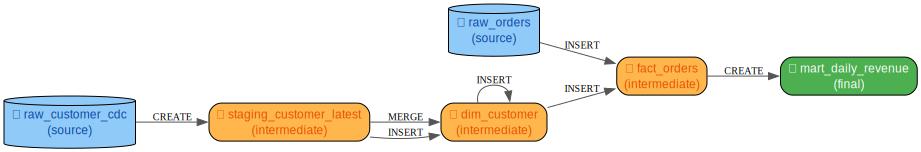

In [2]:
import shutil

from clgraph import visualize_pipeline_lineage, visualize_table_dependencies

if shutil.which("dot") is None:
    print("Graphviz not installed. Install with: brew install graphviz")
else:
    display(visualize_table_dependencies(pipeline.table_graph))

### Column-level lineage (simplified)

The simplified view collapses per-query subquery intermediate nodes but keeps all cross-table flows — ideal for a bird's-eye view.

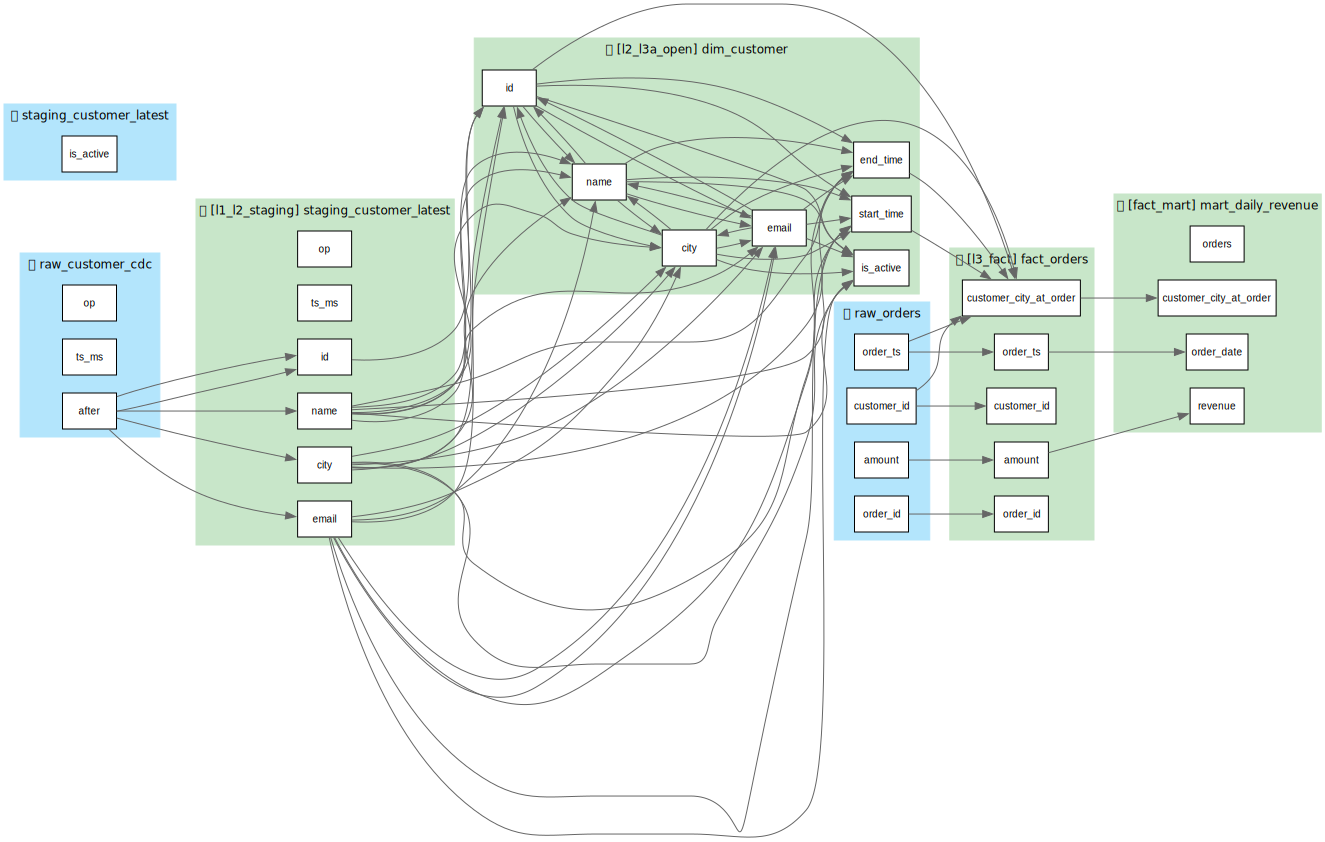

In [3]:
if shutil.which("dot") is None:
    print("Graphviz not installed. Install with: brew install graphviz")
else:
    display(visualize_pipeline_lineage(pipeline.column_graph.to_simplified()))

## 4. What clgraph captures — a gap-by-gap showcase

Each section below demonstrates a lineage feature on the actual pipeline above.

### Gap 1 — Struct dot-access (`after.id`, `after.city`, ...)

Debezium-style CDC envelopes put the row payload under nested structs. sqlglot parses `after.id` as `Column(table="after", name="id")` — indistinguishable from a table-qualified reference. clgraph now detects when `Column.table` can't be resolved as any known table/alias and emits a **struct edge** instead, carrying `nested_path` and `access_type="struct"` metadata.

In [4]:
struct_edges = [e for e in pipeline.edges if e.access_type == "struct"]

print(f"Struct dot-access edges: {len(struct_edges)}\n")
for e in struct_edges:
    print(f"  {e.from_node.full_name:30s} -> {e.to_node.full_name}")
    print(f"      nested_path={e.nested_path!r:12s} access_type={e.access_type!r}")

Struct dot-access edges: 5

  raw_customer_cdc.after         -> l1_l2_staging:subq:subquery_0.rn
      nested_path='.id'        access_type='struct'
  raw_customer_cdc.after         -> staging_customer_latest.id
      nested_path='.id'        access_type='struct'
  raw_customer_cdc.after         -> staging_customer_latest.name
      nested_path='.name'      access_type='struct'
  raw_customer_cdc.after         -> staging_customer_latest.city
      nested_path='.city'      access_type='struct'
  raw_customer_cdc.after         -> staging_customer_latest.email
      nested_path='.email'     access_type='struct'


### Gap 2 — Dedup via subquery + `WHERE rn = 1`

The canonical dedup pattern: `ROW_NUMBER() OVER (PARTITION BY ...)` in a subquery, then `WHERE rn = 1` in the outer query. clgraph detects this shape and promotes qualify metadata — partition / order columns become visible as qualify-context sources of the final output.

In [5]:
qualify_edges = [e for e in pipeline.edges if e.is_qualify_column]

print(f"Qualify (dedup) edges: {len(qualify_edges)}\n")
for e in qualify_edges:
    print(f"  {e.from_node.full_name:40s} -> {e.to_node.full_name}")
    print(f"      qualify_context={e.qualify_context!r}  qualify_function={e.qualify_function!r}")

Qualify (dedup) edges: 1

  raw_customer_cdc.after                   -> staging_customer_latest.id
      qualify_context='partition'  qualify_function='ROW_NUMBER'


### Gap 3 / Gap 10 — MERGE `WHEN MATCHED AND (...)` condition columns

The close-old-row MERGE only fires when `t.name <> s.name OR t.city <> s.city OR t.email <> s.email`. Those columns are not *assigned* — but they **gate** the assignment. Before this fix, impact analysis on `staging.name` would miss that it drives whether `dim_customer.end_time` gets updated.

Condition edges now carry `merge_column_role="condition"` (as distinct from `"assignment"`).

In [6]:
cond_edges = [e for e in pipeline.edges if e.merge_column_role == "condition"]

print(f"MERGE condition edges: {len(cond_edges)}\n")
for e in sorted(cond_edges, key=lambda e: (e.from_node.full_name, e.to_node.full_name)):
    print(f"  {e.from_node.full_name:30s} -> {e.to_node.full_name:50s} ({e.edge_type})")

MERGE condition edges: 13

  staging_customer_latest.city   -> l2_l3a_close:subq:main.end_time                    (merge_update)
  staging_customer_latest.city   -> l2_l3a_close:subq:main.end_time                    (merge_update)
  staging_customer_latest.city   -> l2_l3a_close:subq:main.is_active                   (merge_update)
  staging_customer_latest.city   -> l2_l3a_close:subq:main.is_active                   (merge_update)
  staging_customer_latest.email  -> l2_l3a_close:subq:main.end_time                    (merge_update)
  staging_customer_latest.email  -> l2_l3a_close:subq:main.end_time                    (merge_update)
  staging_customer_latest.email  -> l2_l3a_close:subq:main.is_active                   (merge_update)
  staging_customer_latest.email  -> l2_l3a_close:subq:main.is_active                   (merge_update)
  staging_customer_latest.is_active -> l2_l3a_close:subq:main.is_active                   (merge_match_filter)
  staging_customer_latest.name   -> l2_l3a_clo

### Gap 4 — Self-referencing target across statements

Step 2 (`INSERT INTO dim_customer ... LEFT JOIN dim_customer t`) reads from a table that Step 1 just mutated. Naively, this would produce a self-loop in the pipeline graph. clgraph instead creates **self-read nodes** — statement-scoped representations of the prior table state — and wires a **cross-query self-ref edge** from Step 1's output to Step 2's self-read input.

In [7]:
sr_cols = pipeline.get_self_read_columns("dim_customer")
print(f"Self-read columns for dim_customer: {len(sr_cols)}")
for c in sr_cols:
    print(f"  {c.full_name:60s}  node_type={c.node_type}")

print()
prior_state_edges = [e for e in pipeline.edges if e.edge_role == "prior_state_read"]
cross_query_edges = [e for e in pipeline.edges if e.edge_role == "cross_query_self_ref"]
print(f"prior_state_read edges   (inside step 2): {len(prior_state_edges)}")
print(f"cross_query_self_ref edges (step 1 -> step 2): {len(cross_query_edges)}")

Self-read columns for dim_customer: 4
  l2_l3a_open:self_read:dim_customer.id                         node_type=self_read
  l2_l3a_open:self_read:dim_customer.email                      node_type=self_read
  l2_l3a_open:self_read:dim_customer.name                       node_type=self_read
  l2_l3a_open:self_read:dim_customer.city                       node_type=self_read

prior_state_read edges   (inside step 2): 28
cross_query_self_ref edges (step 1 -> step 2): 4


### Gap 5 — Literal-only output columns (`'Y' AS is_active`)

Columns derived purely from literals (e.g., `'Y' AS is_active`, `TIMESTAMP '9999-12-31 ...'`) appear as terminal output nodes with **zero upstream edges**. They're not silently dropped — they're visible as first-class columns on the dim table.

In [8]:
from collections import defaultdict

# Find output columns with no incoming value edges — these are literal-only or function-only
incoming = defaultdict(list)
for e in pipeline.edges:
    if not e.is_join_predicate and not e.is_where_filter and e.merge_column_role != "condition":
        incoming[e.to_node.full_name].append(e)

dim_output_cols = [
    c for c in pipeline.columns.values() if c.table_name == "dim_customer" and c.layer == "output"
]
print("Literal-only / function-only output columns on dim_customer:\n")
for col in sorted(dim_output_cols, key=lambda c: c.column_name):
    n_value_in = len(incoming.get(col.full_name, []))
    marker = "(literal/function only)" if n_value_in == 0 else f"({n_value_in} value edges)"
    print(f"  {col.column_name:15s} {marker}")

Literal-only / function-only output columns on dim_customer:

  city            (1 value edges)
  email           (1 value edges)
  end_time        (literal/function only)
  id              (1 value edges)
  is_active       (literal/function only)
  name            (1 value edges)
  start_time      (literal/function only)


### Gap 6 — Function-only outputs (`current_timestamp()`)

`current_timestamp()` has no column dependencies — it's a function-only source. The resulting columns (`start_time`, `end_time` after MERGE) appear as outputs in the graph without incoming column edges, visible for downstream impact analysis even though nothing upstream drives their value.

In [9]:
# end_time appears twice: assigned via current_timestamp() in the MERGE,
# and (separately) derived from the '9999-...' literal in the INSERT.
# Both are handled correctly.

end_time_edges = [e for e in pipeline.edges if e.to_node.column_name == "end_time"]
print("Edges targeting *.end_time (by query):")
by_query: dict[str, list] = {}
for e in end_time_edges:
    by_query.setdefault(e.query_id or "?", []).append(e)

for qid, edges in by_query.items():
    print(f"\n  query={qid}")
    for e in edges[:5]:
        print(
            f"    {e.from_node.full_name:50s} -> {e.to_node.full_name} ({e.edge_type}, role={e.merge_column_role})"
        )
    if len(edges) > 5:
        print(f"    ... and {len(edges) - 5} more")

Edges targeting *.end_time (by query):

  query=l2_l3a_close
    staging_customer_latest.email                      -> l2_l3a_close:subq:main.end_time (merge_update, role=condition)
    staging_customer_latest.email                      -> l2_l3a_close:subq:main.end_time (merge_update, role=condition)
    staging_customer_latest.name                       -> l2_l3a_close:subq:main.end_time (merge_update, role=condition)
    staging_customer_latest.name                       -> l2_l3a_close:subq:main.end_time (merge_update, role=condition)
    staging_customer_latest.city                       -> l2_l3a_close:subq:main.end_time (merge_update, role=condition)
    ... and 1 more

  query=l2_l3a_open
    l2_l3a_open:self_read:dim_customer.id              -> dim_customer.end_time (where_filter, role=None)
    l2_l3a_open:self_read:dim_customer.email           -> dim_customer.end_time (where_filter, role=None)
    staging_customer_latest.email                      -> dim_customer.end_time (w

### Gap 7 — JOIN ON predicate columns (including `BETWEEN`)

The fact-table join uses a point-in-time predicate: `o.order_ts BETWEEN d.start_time AND d.end_time`. Before this fix, `d.start_time` and `d.end_time` were invisible to column lineage (the JOIN ON clause wasn't traced at all).

Now predicate-only columns produce **predicate edges** with `is_join_predicate=True` to every output column of the joined query, enabling impact analysis ("if I change the SCD2 `end_time` semantics, what downstream columns are affected?").

In [10]:
join_pred_edges = [e for e in pipeline.edges if e.is_join_predicate]
print(f"JOIN predicate edges: {len(join_pred_edges)}\n")
for e in sorted(join_pred_edges, key=lambda e: (e.from_node.full_name, e.to_node.full_name)):
    print(f"  {e.from_node.full_name:30s} -> {e.to_node.full_name:45s} (side={e.join_side})")

JOIN predicate edges: 5

  dim_customer.end_time          -> fact_orders.customer_city_at_order            (side=right)
  dim_customer.id                -> fact_orders.customer_city_at_order            (side=right)
  dim_customer.start_time        -> fact_orders.customer_city_at_order            (side=right)
  raw_orders.customer_id         -> fact_orders.customer_city_at_order            (side=left)
  raw_orders.order_ts            -> fact_orders.customer_city_at_order            (side=left)


### Gap 8 — WHERE clause columns

WHERE predicates don't produce output values directly, but they gate which rows land. `WHERE t.id IS NULL OR (t.name <> s.name OR t.city <> s.city OR t.email <> s.email)` in Step 2 is the sentinel that distinguishes *new* rows from *changed* rows. Column lineage now records these as `where_filter` edges.

In [11]:
from collections import Counter

where_edges = [e for e in pipeline.edges if e.is_where_filter]
print(f"WHERE filter edges: {len(where_edges)}\n")

# Group by source column to avoid spam — each source predicate column fans out
# to every non-star output column of the query
by_source = Counter(e.from_node.full_name for e in where_edges)
for col, count in by_source.most_common():
    print(f"  {col:40s} -> {count} output columns (where_filter)")

print("\nSample where_condition metadata:")
for e in where_edges[:3]:
    print(f"  {e.from_node.full_name} -> {e.to_node.full_name}")
    print(f"      where_condition={e.where_condition!r}")

WHERE filter edges: 50

  l2_l3a_open:self_read:dim_customer.id    -> 7 output columns (where_filter)
  l2_l3a_open:self_read:dim_customer.email -> 7 output columns (where_filter)
  staging_customer_latest.email            -> 7 output columns (where_filter)
  l2_l3a_open:self_read:dim_customer.name  -> 7 output columns (where_filter)
  staging_customer_latest.name             -> 7 output columns (where_filter)
  l2_l3a_open:self_read:dim_customer.city  -> 7 output columns (where_filter)
  staging_customer_latest.city             -> 7 output columns (where_filter)
  raw_customer_cdc.op                      -> 1 output columns (where_filter)

Sample where_condition metadata:
  raw_customer_cdc.op -> l1_l2_staging:subq:subquery_0.rn
      where_condition="op IN ('c', 'u') /* Deletes filtered out; tombstone handling is a future extension */"
  l2_l3a_open:self_read:dim_customer.id -> dim_customer.id
      where_condition='t.id IS NULL OR (t.name <> s.name OR t.city <> s.city OR t.email <> 

### Gap 9 — MERGE ON literal-bound predicate (`t.is_active = 'Y'`)

The close-old-row MERGE's ON clause is `t.id = s.id AND t.is_active = 'Y'`. The second conjunct is a literal filter — `match_columns` extraction only captures `EQ` column pairs, so before this fix `t.is_active` was dropped. Now it's emitted as a **`merge_match_filter`** edge with `merge_column_role="condition"`.

In [12]:
mmf_edges = [e for e in pipeline.edges if e.edge_type == "merge_match_filter"]
print(f"merge_match_filter edges: {len(mmf_edges)}\n")
for e in mmf_edges:
    print(f"  {e.from_node.full_name:40s} -> {e.to_node.full_name}")
    print(f"      merge_column_role={e.merge_column_role!r}  merge_condition={e.merge_condition!r}")

merge_match_filter edges: 1

  staging_customer_latest.is_active        -> l2_l3a_close:subq:main.is_active
      merge_column_role='condition'  merge_condition=None


## 5. Impact analysis — putting it all together

With all 10 gap features in place, impact analysis queries return realistic, production-accurate answers. Two worked examples:

In [13]:
# Q1: "What downstream columns depend on raw_customer_cdc.after.city?"
#     (The CDC envelope struct field, via dedup -> staging -> SCD2 dim -> fact -> mart)
print("Q1. Forward impact of raw_customer_cdc.after.city:\n")
downstream = pipeline.trace_column_forward("raw_customer_cdc", "after")
by_table: dict[str, list] = {}
for col in downstream:
    by_table.setdefault(col.table_name, []).append(col.column_name)
for table, cols in sorted(by_table.items()):
    print(f"  {table:30s} -> {sorted(set(cols))}")

Q1. Forward impact of raw_customer_cdc.after.city:

  dim_customer                   -> ['city', 'email', 'id', 'is_active', 'name']
  main                           -> ['end_time', 'id', 'is_active']
  mart_daily_revenue             -> ['customer_city_at_order']
  subquery_0                     -> ['rn']


In [14]:
# Q2: "What upstream columns drive mart_daily_revenue.customer_city_at_order?"
print("Q2. Backward trace of mart_daily_revenue.customer_city_at_order:\n")
upstream = pipeline.trace_column_backward("mart_daily_revenue", "customer_city_at_order")
by_table = {}
for col in upstream:
    by_table.setdefault(col.table_name, []).append(col.column_name)
for table, cols in sorted(by_table.items()):
    print(f"  {table:30s} <- {sorted(set(cols))}")

Q2. Backward trace of mart_daily_revenue.customer_city_at_order:

  raw_customer_cdc               <- ['after']
  raw_orders                     <- ['customer_id', 'order_ts']


In [15]:
# Q3: "If we change the SCD2 validity semantics (dim_customer.end_time),
#      what downstream columns in fact_orders / mart are affected via the BETWEEN join?"
print("Q3. Forward impact of dim_customer.end_time (Gap 7 predicate-edge reachability):\n")
downstream = pipeline.trace_column_forward("dim_customer", "end_time")
by_table = {}
for col in downstream:
    by_table.setdefault(col.table_name, []).append(col.column_name)
for table, cols in sorted(by_table.items()):
    print(f"  {table:30s} -> {sorted(set(cols))}")

Q3. Forward impact of dim_customer.end_time (Gap 7 predicate-edge reachability):

  mart_daily_revenue             -> ['customer_city_at_order']


## 6. Edge-metadata summary

A one-glance summary of what this pipeline produces, by edge type / flag.

In [16]:
from collections import Counter

print(f"Total edges: {len(pipeline.edges)}\n")

edge_type_counts = Counter(e.edge_type for e in pipeline.edges)
print("By edge_type:")
for et, n in edge_type_counts.most_common():
    print(f"  {et:25s} {n}")

print("\nBy feature flag:")
flag_counts = {
    "is_join_predicate": sum(1 for e in pipeline.edges if e.is_join_predicate),
    "is_where_filter": sum(1 for e in pipeline.edges if e.is_where_filter),
    "is_qualify_column": sum(1 for e in pipeline.edges if e.is_qualify_column),
    "access_type=struct": sum(1 for e in pipeline.edges if e.access_type == "struct"),
    "merge_column_role=condition": sum(
        1 for e in pipeline.edges if e.merge_column_role == "condition"
    ),
    "merge_column_role=assignment": sum(
        1 for e in pipeline.edges if e.merge_column_role == "assignment"
    ),
    "edge_role=prior_state_read": sum(
        1 for e in pipeline.edges if e.edge_role == "prior_state_read"
    ),
    "edge_role=cross_query_self_ref": sum(
        1 for e in pipeline.edges if e.edge_role == "cross_query_self_ref"
    ),
}
for flag, n in flag_counts.items():
    print(f"  {flag:35s} {n}")

Total edges: 95

By edge_type:
  where_filter              50
  merge_update              12
  direct_column             9
  expression                6
  join_predicate            5
  cross_query_self_ref      4
  window                    2
  star_passthrough          1
  window_partition          1
  window_order              1
  qualify_partition         1
  merge_match               1
  merge_match_filter        1
  aggregate                 1

By feature flag:
  is_join_predicate                   5
  is_where_filter                     50
  is_qualify_column                   1
  access_type=struct                  5
  merge_column_role=condition         13
  merge_column_role=assignment        0
  edge_role=prior_state_read          28
  edge_role=cross_query_self_ref      4


## 7. Further reading

- **Design doc:** `docs/superpowers/specs/2026-04-13-cdc-scd-pipeline-gaps-design.md`
- **Gap-specific designs:**
  - `2026-04-13-gap4-self-referencing-target-design.md`
  - `2026-04-13-gap7-join-predicate-columns-design.md`
  - `2026-04-14-gaps-1-2-8-design.md`
- **Focused examples:**
  - `examples/self_referencing_lineage.ipynb` — Gap 4 in isolation
  - `examples/join_predicate_lineage.ipynb` — Gap 7 in isolation
  - `examples/merge_lineage.ipynb` — Gap 3/9/10 MERGE mechanics
- **Integration tests:** `tests/test_cdc_scd_pipeline.py`